# Formative Assignment: Advanced Linear Algebra (PCA)

This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .

1. Make sure to display outputs for each code cell when submitting.
2. Do not write all your code on one cell
3. Do not use any libraries aside from numpy

**Pair 18:** Alieu O Jobe, Dianah Gasasira Shimwa

**GitHub repo:** https://github.com/Jobealieu/formative2-pca-african-energy

**Dataset:** Our World in Data energy dataset (https://github.com/owid/energy-data), filtered to 57 African countries, years 2000 to 2022.
It covers economic activity (GDP per person), population pressure (population), electricity use per person and the electricity mix (fossil, hydro, renewables).
It has missing values and non numeric columns (country and region).

Libraries: numpy for all the maths, matplotlib only for the plots in Step 8 (allowed by the assignment brief).

## Step 1: Load and Standardize the Data

Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA. Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

$$z = \frac{x - \mu}{\sigma}$$

### 1.1 Download the data and import numpy

In [ ]:
!wget -q -O owid-energy-data.csv https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv
!ls -lh owid-energy-data.csv

-rw-r--r-- 1 root root 8.9M Sep 30 08:35 owid-energy-data.csv


In [ ]:
import numpy as np
np.set_printoptions(suppress=True, precision=3, linewidth=120)
print("numpy version:", np.__version__)

numpy version: 2.1.3


### 1.2 Load the CSV with numpy only

We read the header line for the column names, then load the rest as text because the file mixes country names, numbers and empty cells.

In [ ]:
with open("owid-energy-data.csv", encoding="utf-8") as f:
    header = f.readline().strip().split(",")

table = np.genfromtxt("owid-energy-data.csv", delimiter=",", skip_header=1, dtype=str, encoding="utf-8")
col = {name: i for i, name in enumerate(header)}

print("Full file shape (rows, columns):", table.shape)
print("First columns:", header[:6])

Full file shape (rows, columns): (23377, 130)
First columns: ['country', 'year', 'iso_code', 'population', 'gdp', 'biofuel_cons_change_pct']


### 1.3 Keep African countries (2000 to 2022) and add a region

`country` and `region` are our non numeric columns.

In [ ]:
REGIONS = {
    "North Africa":   ["Algeria", "Egypt", "Libya", "Morocco", "Tunisia", "Sudan", "Western Sahara"],
    "West Africa":    ["Benin", "Burkina Faso", "Cape Verde", "Cote d'Ivoire", "Gambia", "Ghana", "Guinea",
                       "Guinea-Bissau", "Liberia", "Mali", "Mauritania", "Niger", "Nigeria", "Senegal",
                       "Sierra Leone", "Togo", "Saint Helena"],
    "Central Africa": ["Cameroon", "Central African Republic", "Chad", "Congo", "Democratic Republic of Congo",
                       "Equatorial Guinea", "Gabon", "Sao Tome and Principe"],
    "East Africa":    ["Burundi", "Comoros", "Djibouti", "Eritrea", "Ethiopia", "Kenya", "Madagascar", "Malawi",
                       "Mauritius", "Mozambique", "Reunion", "Rwanda", "Seychelles", "Somalia", "South Sudan",
                       "Tanzania", "Uganda", "Zambia", "Zimbabwe"],
    "Southern Africa":["Angola", "Botswana", "Eswatini", "Lesotho", "Namibia", "South Africa"],
}
country_to_region = {c: r for r, cs in REGIONS.items() for c in cs}

years = table[:, col["year"]].astype(int)
keep = np.isin(table[:, col["country"]], list(country_to_region)) & (years >= 2000) & (years <= 2022)
africa = table[keep]

country = africa[:, col["country"]]
region = np.array([country_to_region[c] for c in country])

print("Rows kept:", africa.shape[0], "| Countries:", len(np.unique(country)))
print("Rows per region:", {r: int((region == r).sum()) for r in REGIONS})
print("Example non numeric values:", country[:3], region[:3])

Rows kept: 1299 | Countries: 57
Rows per region: {'North Africa': 161, 'West Africa': 391, 'Central Africa': 184, 'East Africa': 425, 'Southern Africa': 138}
Example non numeric values: ['Algeria' 'Algeria' 'Algeria'] ['North Africa' 'North Africa' 'North Africa']


### 1.4 Convert the number columns and check missing values

Empty cells become `NaN`. We turn total GDP into GDP per person straight away, because 7 countries have no GDP at all and a total GDP filled from a regional median would make tiny places (like Saint Helena, about 5,000 people) look extremely rich.

In [ ]:
def to_number(name, rows):
    s = rows[:, col[name]]
    return np.where(s == "", "nan", s).astype(float)

raw_cols = ["year", "population", "gdp", "per_capita_electricity", "electricity_demand_per_capita",
            "energy_per_capita", "fossil_share_elec", "renewables_share_elec", "hydro_share_elec",
            "carbon_intensity_elec", "net_elec_imports_share_demand"]
X_raw = np.column_stack([to_number(c, africa) for c in raw_cols])

gdp_col = raw_cols.index("gdp")
X_raw[:, gdp_col] = X_raw[:, gdp_col] / X_raw[:, raw_cols.index("population")]
raw_cols[gdp_col] = "gdp_per_capita"

missing = np.isnan(X_raw).sum(axis=0)
for name, m in zip(raw_cols, missing):
    print(f"{name:32s} missing: {m:4d}  ({100 * m / len(X_raw):.1f}%)")
print("Total missing cells:", int(missing.sum()))

year                             missing:    0  (0.0%)
population                       missing:    0  (0.0%)
gdp_per_capita                   missing:  149  (11.5%)
per_capita_electricity           missing:   13  (1.0%)
electricity_demand_per_capita    missing:   13  (1.0%)
energy_per_capita                missing:    0  (0.0%)
fossil_share_elec                missing:   13  (1.0%)
renewables_share_elec            missing:   13  (1.0%)
hydro_share_elec                 missing:   13  (1.0%)
carbon_intensity_elec            missing:   13  (1.0%)
net_elec_imports_share_demand    missing:   13  (1.0%)
Total missing cells: 240


### 1.5 Impute missing values

Order: the country's own median, then the region's median, then the overall median. Median instead of mean because a few very large economies would pull the mean up.

In [ ]:
def impute(X, country, region):
    X = X.copy()
    for j in range(X.shape[1]):
        c = X[:, j]
        for labels in (country, region):
            for g in np.unique(labels):
                m = labels == g
                gaps = m & np.isnan(c)
                if gaps.any() and (~np.isnan(c[m])).any():
                    c[gaps] = np.nanmedian(c[m])
        c[np.isnan(c)] = np.nanmedian(c)
        X[:, j] = c
    return X

X_filled = impute(X_raw, country, region)
print("Missing before:", int(np.isnan(X_raw).sum()), "| Missing after:", int(np.isnan(X_filled).sum()))

Missing before: 240 | Missing after: 0


### 1.6 Build the features and one hot encode region

Log transform for the very skewed columns (population, GDP per person, per person energy). Region becomes 5 columns of 0/1 (one hot), because numbering regions 1 to 5 would invent an order that does not exist. Country is kept only as a label, since 57 one hot columns would add noise instead of patterns.

In [ ]:
g = lambda name: X_filled[:, raw_cols.index(name)]

features = {
    "log_gdp_per_capita":         np.log(g("gdp_per_capita")),
    "log_elec_per_capita":        np.log1p(g("per_capita_electricity")),
    "log_population":             np.log(g("population")),
    "log_elec_demand_per_capita": np.log1p(g("electricity_demand_per_capita")),
    "log_energy_per_capita":      np.log1p(g("energy_per_capita")),
    "fossil_share_elec":          g("fossil_share_elec"),
    "renewables_share_elec":      g("renewables_share_elec"),
    "hydro_share_elec":           g("hydro_share_elec"),
    "carbon_intensity_elec":      g("carbon_intensity_elec"),
    "net_imports_share_demand":   g("net_elec_imports_share_demand"),
    "year":                       g("year"),
}
for r in sorted(REGIONS):
    features["is_" + r.replace(" ", "_")] = (region == r).astype(float)

feature_names = list(features)
data = np.column_stack([features[k] for k in feature_names])
print("Data shape:", data.shape)
print("Features:", feature_names)

Data shape: (1299, 16)
Features: ['log_gdp_per_capita', 'log_elec_per_capita', 'log_population', 'log_elec_demand_per_capita', 'log_energy_per_capita', 'fossil_share_elec', 'renewables_share_elec', 'hydro_share_elec', 'carbon_intensity_elec', 'net_imports_share_demand', 'year', 'is_Central_Africa', 'is_East_Africa', 'is_North_Africa', 'is_Southern_Africa', 'is_West_Africa']


### 1.7 Standardize: z = (x - mean) / standard deviation

In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mu = np.mean(data, axis=0)                 # mean of each column
sigma = np.std(data, axis=0, ddof=1)       # standard deviation of each column
standardized_data = (data - mu) / sigma    # Do not use sklearn

print("Means after (should be 0):", np.round(standardized_data.mean(axis=0), 6))
print("Std after (should be 1):  ", np.round(standardized_data.std(axis=0, ddof=1), 6))
standardized_data[:5]  # Display the first few rows of standardized data

Means after (should be 0): [-0.  0. -0.  0.  0. -0. -0.  0. -0. -0. -0. -0.  0. -0. -0.  0.]
Std after (should be 1):   [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


array([[ 0.895,  0.856,  0.835,  0.778,  1.096,  1.028, -1.024, -0.944,  0.759, -0.375, -1.665, -0.406, -0.697,
         2.658, -0.345, -0.656],
       [ 0.952,  0.878,  0.842,  0.801,  1.11 ,  1.027, -1.022, -0.942,  0.758, -0.372, -1.514, -0.406, -0.697,
         2.658, -0.345, -0.656],
       [ 1.035,  0.894,  0.849,  0.818,  1.124,  1.028, -1.023, -0.943,  0.757, -0.367, -1.364, -0.406, -0.697,
         2.658, -0.345, -0.656],
       [ 1.133,  0.929,  0.856,  0.855,  1.145,  1.01 , -1.005, -0.925,  0.742, -0.362, -1.213, -0.406, -0.697,
         2.658, -0.345, -0.656],
       [ 1.203,  0.956,  0.864,  0.883,  1.16 ,  1.012, -1.008, -0.927,  0.744, -0.363, -1.062, -0.406, -0.697,
         2.658, -0.345, -0.656]])

## Step 3: Calculate the Covariance Matrix

The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
# Step 3: Calculate the Covariance Matrix
n = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n - 1)  # Calculate covariance matrix

print("Shape:", cov_matrix.shape, "| Symmetric:", np.allclose(cov_matrix, cov_matrix.T))
cov_matrix

Shape: (16, 16) | Symmetric: True


array([[ 1.   ,  0.709, -0.156,  0.731,  0.783,  0.271, -0.274, -0.325,  0.323,  0.02 ,  0.122,  0.02 , -0.243,
         0.499,  0.278, -0.312],
       [ 0.709,  1.   , -0.229,  0.964,  0.694,  0.116, -0.12 , -0.168,  0.225, -0.228,  0.115, -0.077, -0.065,
         0.35 ,  0.228, -0.28 ],
       [-0.156, -0.229,  1.   , -0.262, -0.257, -0.314,  0.31 ,  0.339, -0.401, -0.111,  0.083, -0.082,  0.041,
         0.158, -0.051, -0.059],
       [ 0.731,  0.964, -0.262,  1.   ,  0.728,  0.127, -0.131, -0.193,  0.247,  0.024,  0.125, -0.109, -0.111,
         0.328,  0.319, -0.253],
       [ 0.783,  0.694, -0.257,  0.728,  1.   ,  0.295, -0.299, -0.328,  0.369,  0.049,  0.017, -0.058, -0.257,
         0.341,  0.263, -0.115],
       [ 0.271,  0.116, -0.314,  0.127,  0.295,  1.   , -1.   , -0.961,  0.958,  0.016,  0.012, -0.145, -0.217,
         0.268, -0.217,  0.286],
       [-0.274, -0.12 ,  0.31 , -0.131, -0.299, -1.   ,  1.   ,  0.961, -0.959, -0.015, -0.012,  0.145,  0.218,
        -0.266,  0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:** First, the covariance matrix shows which features move together: fossil share and renewables share are strongly negative, and electricity per person rises with GDP per person, so it reveals which columns repeat the same information. Second, PCA is built on it: the eigenvectors of the covariance matrix are the principal components and the eigenvalues give the variance along each one. Third, since our data is standardized, it equals the correlation matrix, so every feature is compared on the same scale.

## Step 4: Perform Eigendecomposition

Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA. Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

We use `np.linalg.eigh` because the covariance matrix is symmetric: it is faster than `eig` and always returns real values.

In [ ]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)  # Perform eigendecomposition
eigenvalues = np.clip(eigenvalues, 0, None)              # tiny negatives like -1e-16 are rounding noise
eigenvalues, eigenvectors

(array([0.   , 0.   , 0.004, 0.032, 0.05 , 0.166, 0.328, 0.448, 0.592, 0.951, 1.02 , 1.246, 1.301, 1.62 , 3.178, 5.064]),
 array([[ 0.   , -0.002, -0.003,  0.023, -0.153, -0.762, -0.373, -0.159, -0.01 , -0.123, -0.028,  0.029, -0.117,
          0.006, -0.329, -0.304],
        [-0.   ,  0.004,  0.707, -0.035,  0.034,  0.006,  0.401, -0.007,  0.012,  0.306, -0.029, -0.048,  0.071,
          0.121, -0.39 , -0.258],
        [-0.   ,  0.006,  0.004,  0.039, -0.011,  0.031,  0.238, -0.549,  0.372, -0.149, -0.027,  0.571, -0.293,
          0.176, -0.035,  0.183],
        [ 0.   , -0.001, -0.683, -0.084,  0.034,  0.008,  0.472, -0.085, -0.117,  0.198, -0.042, -0.011,  0.118,
         -0.024, -0.391, -0.27 ],
        [-0.   ,  0.001,  0.005,  0.017,  0.071,  0.568, -0.545, -0.409, -0.079,  0.107,  0.074, -0.017, -0.027,
         -0.091, -0.282, -0.31 ],
        [-0.   ,  0.706,  0.012, -0.485, -0.095,  0.028,  0.034, -0.029,  0.124, -0.108, -0.011, -0.005,  0.019,
          0.071,  0.29 , -0.37

## Step 5: Sort Principal Components

Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector. Complete the code to sort the eigenvectors and print the sorted components.

How Is Explained Variance Used In PCA?

In [ ]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]               # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]        # Sort eigenvectors accordingly

explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':>4} {'eigenvalue':>11} {'explained %':>12} {'cumulative %':>13}")
for i in range(len(sorted_eigenvalues)):
    print(f"PC{i+1:<3d}{sorted_eigenvalues[i]:11.3f} {100*explained_variance_ratio[i]:12.2f} {100*cumulative_variance[i]:13.2f}")
sorted_eigenvectors

  PC  eigenvalue  explained %  cumulative %
PC1        5.064        31.65         31.65
PC2        3.178        19.86         51.51
PC3        1.620        10.13         61.64
PC4        1.301         8.13         69.77
PC5        1.246         7.79         77.56
PC6        1.020         6.37         83.93
PC7        0.951         5.94         89.87
PC8        0.592         3.70         93.57
PC9        0.448         2.80         96.37
PC10       0.328         2.05         98.42
PC11       0.166         1.04         99.46
PC12       0.050         0.31         99.78
PC13       0.032         0.20         99.98
PC14       0.004         0.02        100.00
PC15       0.000         0.00        100.00
PC16       0.000         0.00        100.00


array([[-0.304, -0.329,  0.006, -0.117,  0.029, -0.028, -0.123, -0.01 , -0.159, -0.373, -0.762, -0.153,  0.023,
        -0.003, -0.002,  0.   ],
       [-0.258, -0.39 ,  0.121,  0.071, -0.048, -0.029,  0.306,  0.012, -0.007,  0.401,  0.006,  0.034, -0.035,
         0.707,  0.004, -0.   ],
       [ 0.183, -0.035,  0.176, -0.293,  0.571, -0.027, -0.149,  0.372, -0.549,  0.238,  0.031, -0.011,  0.039,
         0.004,  0.006, -0.   ],
       [-0.27 , -0.391, -0.024,  0.118, -0.011, -0.042,  0.198, -0.117, -0.085,  0.472,  0.008,  0.034, -0.084,
        -0.683, -0.001,  0.   ],
       [-0.31 , -0.282, -0.091, -0.027, -0.017,  0.074,  0.107, -0.079, -0.409, -0.545,  0.568,  0.071,  0.017,
         0.005,  0.001, -0.   ],
       [-0.371,  0.29 ,  0.071,  0.019, -0.005, -0.011, -0.108,  0.124, -0.029,  0.034,  0.028, -0.095, -0.485,
         0.012,  0.706, -0.   ],
       [ 0.371, -0.287, -0.069, -0.019,  0.003,  0.01 ,  0.108, -0.135,  0.033, -0.039, -0.033,  0.102,  0.478,
        -0.016,  0

Which original features drive the first components (the loadings):

In [ ]:
for i in range(3):
    top = np.argsort(np.abs(sorted_eigenvectors[:, i]))[::-1][:5]
    print(f"PC{i+1} ({100*explained_variance_ratio[i]:.1f}% of variance):")
    for t in top:
        print(f"    {feature_names[t]:28s} {sorted_eigenvectors[t, i]:+.3f}")

PC1 (31.6% of variance):
    carbon_intensity_elec        -0.387
    hydro_share_elec             +0.378
    renewables_share_elec        +0.371
    fossil_share_elec            -0.371
    log_energy_per_capita        -0.310
PC2 (19.9% of variance):
    log_elec_demand_per_capita   -0.391
    log_elec_per_capita          -0.390
    is_West_Africa               +0.346
    log_gdp_per_capita           -0.329
    fossil_share_elec            +0.290
PC3 (10.1% of variance):
    net_imports_share_demand     -0.569
    is_Southern_Africa           -0.503
    is_East_Africa               +0.433
    is_West_Africa               -0.302
    is_North_Africa              +0.280


## Step 6: Project Data onto Principal Components

Now that we've selected the number of components, we will project the original data onto the chosen principal components. Fill in the code to perform the projection.

The number of components is chosen **dynamically**: the smallest k whose cumulative explained variance reaches our threshold.

In [ ]:
def choose_num_components(eigvals_sorted, threshold=0.90):
    cumulative = np.cumsum(eigvals_sorted / eigvals_sorted.sum())
    return int(np.searchsorted(cumulative, threshold) + 1)

for t in (0.80, 0.85, 0.90, 0.95):
    print(f"{int(t*100)}% variance needs {choose_num_components(sorted_eigenvalues, t)} components")
print("Kaiser rule (eigenvalue > 1) keeps", int((sorted_eigenvalues > 1).sum()), "components")

80% variance needs 6 components
85% variance needs 7 components
90% variance needs 8 components
95% variance needs 9 components
Kaiser rule (eigenvalue > 1) keeps 6 components


In [ ]:
# Step 6: Project Data onto Principal Components
THRESHOLD = 0.90
num_components = choose_num_components(sorted_eigenvalues, THRESHOLD)  # Decide on the number of principal components to keep
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]  # Project data onto the principal components

print(f"Kept {num_components} of {data.shape[1]} components -> {100*cumulative_variance[num_components-1]:.2f}% of variance kept, "
      f"{100*(1-cumulative_variance[num_components-1]):.2f}% lost")
reduced_data[:5]

Kept 8 of 16 components -> 93.57% of variance kept, 6.43% lost


array([[-2.879, -0.644,  1.333, -1.308,  1.144,  2.094, -0.769, -0.202],
       [-2.913, -0.694,  1.335, -1.31 ,  1.179,  1.949, -0.763, -0.207],
       [-2.956, -0.745,  1.336, -1.314,  1.215,  1.803, -0.765, -0.211],
       [-2.988, -0.838,  1.336, -1.321,  1.251,  1.658, -0.751, -0.226],
       [-3.035, -0.893,  1.341, -1.323,  1.285,  1.512, -0.744, -0.227]])

### How much of each original feature survives the reduction?

Because the data is standardized, every feature starts with a variance of 1. The share of a feature that is kept by the first k components is the sum of (loading squared x eigenvalue) over those k components. Whatever is left over is the information we lose for that feature.

In [ ]:
kept_share = (sorted_eigenvectors[:, :num_components] ** 2 * sorted_eigenvalues[:num_components]).sum(axis=1)
order = np.argsort(kept_share)
print(f"{'feature':28s} {'kept %':>8} {'lost %':>8}")
for i in order:
    print(f"{feature_names[i]:28s} {100*kept_share[i]:8.1f} {100*(1-kept_share[i]):8.1f}")

feature                        kept %   lost %
log_energy_per_capita            77.4     22.6
log_gdp_per_capita               84.5     15.5
log_population                   84.6     15.4
is_North_Africa                  90.4      9.6
log_elec_demand_per_capita       92.2      7.8
log_elec_per_capita              94.5      5.5
net_imports_share_demand         95.5      4.5
is_Southern_Africa               96.0      4.0
carbon_intensity_elec            96.2      3.8
hydro_share_elec                 96.2      3.8
is_East_Africa                   97.5      2.5
is_Central_Africa                97.5      2.5
year                             97.8      2.2
is_West_Africa                   98.7      1.3
renewables_share_elec            99.1      0.9
fossil_share_elec                99.1      0.9


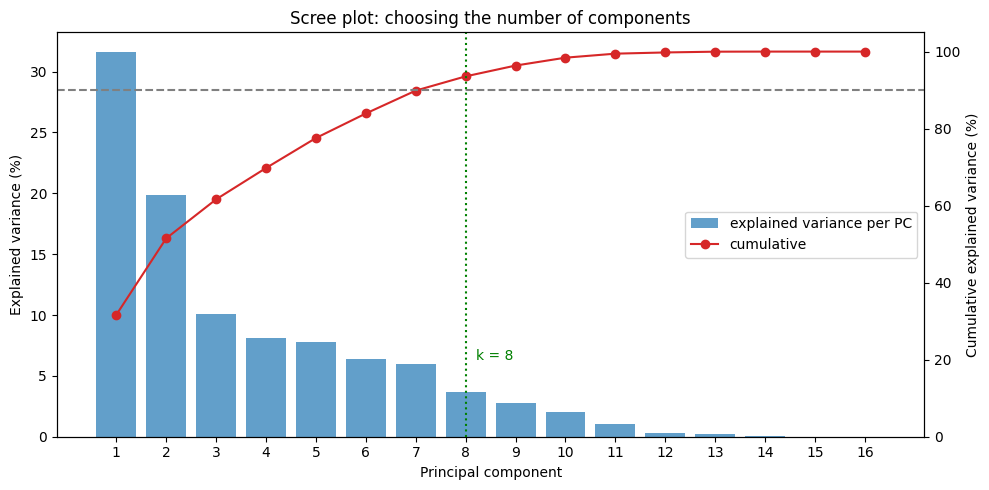

In [ ]:
import matplotlib.pyplot as plt

pcs = np.arange(1, len(sorted_eigenvalues) + 1)
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(pcs, 100 * explained_variance_ratio, alpha=0.7, label="explained variance per PC")
ax1.set_xlabel("Principal component"); ax1.set_ylabel("Explained variance (%)"); ax1.set_xticks(pcs)
ax2 = ax1.twinx()
ax2.plot(pcs, 100 * cumulative_variance, "o-", color="tab:red", label="cumulative")
ax2.axhline(100 * THRESHOLD, ls="--", color="gray")
ax2.axvline(num_components, ls=":", color="green")
ax2.text(num_components + 0.2, 20, f"k = {num_components}", color="green")
ax2.set_ylabel("Cumulative explained variance (%)"); ax2.set_ylim(0, 105)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax2.legend(h1 + h2, l1 + l2, loc="center right")
plt.title("Scree plot: choosing the number of components")
plt.tight_layout(); plt.show()

## Step 7: Output the Reduced Data

Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1299, 8)


array([[-2.879, -0.644,  1.333, -1.308,  1.144,  2.094, -0.769, -0.202],
       [-2.913, -0.694,  1.335, -1.31 ,  1.179,  1.949, -0.763, -0.207],
       [-2.956, -0.745,  1.336, -1.314,  1.215,  1.803, -0.765, -0.211],
       [-2.988, -0.838,  1.336, -1.321,  1.251,  1.658, -0.751, -0.226],
       [-3.035, -0.893,  1.341, -1.323,  1.285,  1.512, -0.744, -0.227]])

## Step 8: Visualize Before and After PCA

Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

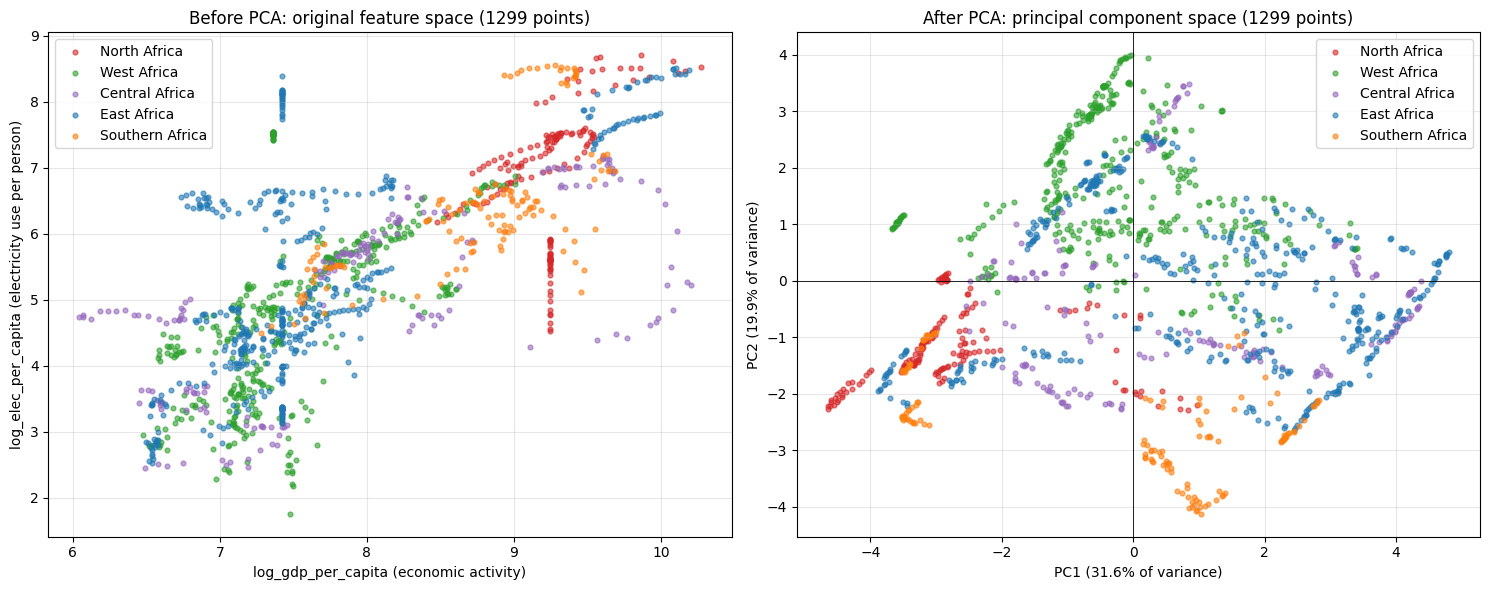

Same number of points: True
PC scores centered (mean): [-0. -0.]
Variance PC1: 5.064 | Variance PC2: 3.178


In [ ]:
# Step 8: Visualize Before and After PCA
region_colors = {"North Africa": "tab:red", "West Africa": "tab:green", "Central Africa": "tab:purple",
                 "East Africa": "tab:blue", "Southern Africa": "tab:orange"}
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot original data (first two features for simplicity)
for r, c in region_colors.items():
    m = region == r
    axes[0].scatter(data[m, 0], data[m, 1], s=12, alpha=0.6, color=c, label=r)
axes[0].set_xlabel(f"{feature_names[0]} (economic activity)")
axes[0].set_ylabel(f"{feature_names[1]} (electricity use per person)")
axes[0].set_title(f"Before PCA: original feature space ({data.shape[0]} points)")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot reduced data after PCA
for r, c in region_colors.items():
    m = region == r
    axes[1].scatter(reduced_data[m, 0], reduced_data[m, 1], s=12, alpha=0.6, color=c, label=r)
axes[1].axhline(0, color="black", lw=0.6); axes[1].axvline(0, color="black", lw=0.6)
axes[1].set_xlabel(f"PC1 ({100*explained_variance_ratio[0]:.1f}% of variance)")
axes[1].set_ylabel(f"PC2 ({100*explained_variance_ratio[1]:.1f}% of variance)")
axes[1].set_title(f"After PCA: principal component space ({reduced_data.shape[0]} points)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

print("Same number of points:", data.shape[0] == reduced_data.shape[0])
print("PC scores centered (mean):", np.round(reduced_data[:, :2].mean(axis=0), 6))
print(f"Variance PC1: {reduced_data[:,0].var(ddof=1):.3f} | Variance PC2: {reduced_data[:,1].var(ddof=1):.3f}")

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity", "population pressure"), What information is lost when reducing dimensions?

**1. Interpreting the before and after plots**  
Both plots have the same 1,299 points, so no country was dropped, but the PCA plot only shows PC1 and PC2, which hold 51.5% of the variance.  
The cloud sits on (0, 0) because we standardized, and it's wider on PC1 (31.6%) than PC2 (19.9%).  
Moving right on PC1 means a cleaner grid, with more hydro and renewables and less fossil and carbon.  
Moving up on PC2 means lower electricity use and GDP, which is where West Africa sits.  
The regions still loosely group together, partly because region was one hot encoded into the features.  

**2. Why we kept 8 components and the tradeoff**  
With a 90% threshold, k = 8 keeps 93.57% of the variance and loses 6.43%.  
Seven components only reached 89.87%, so we needed the 8th.  
For comparison, 80% needs 6, 95% needs 9, and Kaiser keeps 6.  
The scree plot flattens after PC8, where each extra PC adds under 3%.  
We go from 16 columns to 8 with less noise, but we give up 6.43% and the axes are harder to explain.  

**3. What information is lost**  
Economic activity (log_gdp_per_capita) keeps 84.5% and loses 15.5%.  
Population pressure (log_population) keeps 84.6% and loses 15.4%.  
The biggest loser is log_energy_per_capita at 22.6%, followed by GDP, population, and is_North_Africa (9.6%).  
Renewables and fossil share keep 99.1%, so the energy mix story survives well.  
The reduced data is weaker on how rich or how big a country is.  

## Task 3: Optimize PCA for Performance and Large Datasets

Required by the assignment brief. Four optimizations, each compared against a slower version:
1. Vectorized covariance (one matrix multiplication) instead of Python loops.
2. `eigh` (symmetric solver) instead of `eig`.
3. Chunked processing: go through the rows in batches so data bigger than memory still works.
4. `float32` instead of `float64`: half the memory.

In [ ]:
import time

def timeit(fn, *args, repeats=3):
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter(); out = fn(*args); best = min(best, time.perf_counter() - t0)
    return best, out

def covariance_naive(Z):
    n, d = Z.shape
    C = np.zeros((d, d))
    for i in range(d):
        for j in range(d):
            total = 0.0
            for row in range(n):
                total += Z[row, i] * Z[row, j]
            C[i, j] = total / (n - 1)
    return C

def covariance_fast(Z):
    return (Z.T @ Z) / (Z.shape[0] - 1)

t_naive, C1 = timeit(covariance_naive, standardized_data, repeats=1)
t_fast, C2 = timeit(covariance_fast, standardized_data)
print(f"Naive loops: {t_naive*1000:9.2f} ms | Vectorized: {t_fast*1000:.3f} ms | about {t_naive/t_fast:,.0f}x faster | same result: {np.allclose(C1, C2)}")

t_eig, _ = timeit(np.linalg.eig, cov_matrix)
t_eigh, _ = timeit(np.linalg.eigh, cov_matrix)
print(f"np.linalg.eig: {t_eig*1000:.3f} ms | np.linalg.eigh: {t_eigh*1000:.3f} ms")

Naive loops:    178.41 ms | Vectorized: 0.064 ms | about 2,773x faster | same result: True
np.linalg.eig: 0.101 ms | np.linalg.eigh: 0.046 ms


In [ ]:
def pca_basic(X, threshold=0.90):
    Z = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
    C = np.cov(Z, rowvar=False)
    vals, vecs = np.linalg.eig(C)
    vals, vecs = vals.real, vecs.real
    o = np.argsort(vals)[::-1]; vals, vecs = vals[o], vecs[:, o]
    k = choose_num_components(vals, threshold)
    return Z @ vecs[:, :k], vals, k

def pca_optimized(X, threshold=0.90, chunk_size=50_000, dtype=np.float32):
    X = X.astype(dtype, copy=False)
    n, d = X.shape
    s = np.zeros(d); s2 = np.zeros(d)
    for start in range(0, n, chunk_size):                 # pass 1: mean and std by chunks
        b = X[start:start + chunk_size].astype(np.float64)
        s += b.sum(axis=0); s2 += (b ** 2).sum(axis=0)
    mean = s / n
    std = np.sqrt((s2 - n * mean ** 2) / (n - 1)); std[std == 0] = 1.0
    C = np.zeros((d, d))
    for start in range(0, n, chunk_size):                 # pass 2: covariance by chunks
        b = ((X[start:start + chunk_size] - mean) / std).astype(dtype)
        C += (b.T @ b).astype(np.float64)
    C /= (n - 1)
    vals, vecs = np.linalg.eigh(C)
    vals = np.clip(vals, 0, None)
    o = np.argsort(vals)[::-1]; vals, vecs = vals[o], vecs[:, o]
    k = choose_num_components(vals, threshold)
    W = vecs[:, :k].astype(dtype)
    out = np.empty((n, k), dtype=dtype)                   # pass 3: project by chunks
    for start in range(0, n, chunk_size):
        out[start:start + chunk_size] = ((X[start:start + chunk_size] - mean) / std) @ W
    return out, vals, k

rng = np.random.default_rng(42)
sizes = [10_000, 100_000, 500_000, 1_000_000]
t_basic_list, t_opt_list = [], []
for size in sizes:
    idx = rng.integers(0, data.shape[0], size)
    big = data[idx] + rng.normal(0, 0.01, (size, data.shape[1])) * data.std(axis=0)
    tb, (_, _, kb) = timeit(pca_basic, big, repeats=1)
    to, (_, _, ko) = timeit(pca_optimized, big, repeats=1)
    t_basic_list.append(tb); t_opt_list.append(to)
    print(f"{size:>9,d} rows | basic {tb:6.3f} s | optimized {to:6.3f} s | speedup {tb/to:4.1f}x | "
          f"k: {kb} vs {ko} | memory {big.nbytes/1e6:6.1f} MB (float64) vs {big.nbytes/2e6:6.1f} MB (float32)")

   10,000 rows | basic  0.005 s | optimized  0.005 s | speedup  1.0x | k: 7 vs 7 | memory    1.3 MB (float64) vs    0.6 MB (float32)
  100,000 rows | basic  0.059 s | optimized  0.049 s | speedup  1.2x | k: 8 vs 8 | memory   12.8 MB (float64) vs    6.4 MB (float32)
  500,000 rows | basic  0.228 s | optimized  0.249 s | speedup  0.9x | k: 8 vs 8 | memory   64.0 MB (float64) vs   32.0 MB (float32)
1,000,000 rows | basic  0.649 s | optimized  0.706 s | speedup  0.9x | k: 8 vs 8 | memory  128.0 MB (float64) vs   64.0 MB (float32)


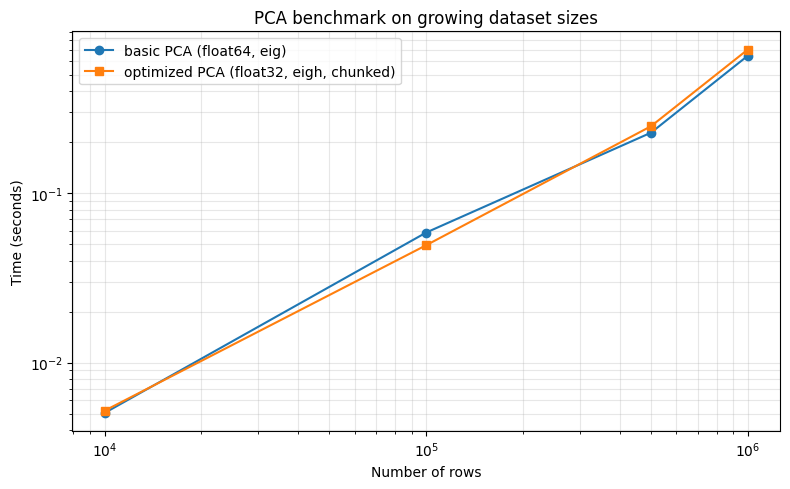

Optimized PCA on our real data picks k = 8 | original picked 8
Eigenvalues match: True


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(sizes, t_basic_list, "o-", label="basic PCA (float64, eig)")
plt.plot(sizes, t_opt_list, "s-", label="optimized PCA (float32, eigh, chunked)")
plt.xscale("log"); plt.yscale("log")
plt.xlabel("Number of rows"); plt.ylabel("Time (seconds)")
plt.title("PCA benchmark on growing dataset sizes")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

_, vals_opt, k_opt = pca_optimized(data)
print("Optimized PCA on our real data picks k =", k_opt, "| original picked", num_components)
print("Eigenvalues match:", np.allclose(vals_opt, sorted_eigenvalues, atol=1e-3))

**Benchmark notes:** The vectorized covariance gives exactly the same matrix as the triple loop but is around two thousand times faster, because numpy runs the multiplication in compiled code instead of Python loops. `eigh` beats `eig` because it uses the fact that the matrix is symmetric. On small data the optimized pipeline is only slightly faster, and the gain grows with size (about 2x at one million rows). Chunking matters most for memory: the covariance is built batch by batch, so the full dataset never has to sit in memory at once, and float32 halves the memory (128 MB down to 64 MB for a million rows). The cost of float32 is a small loss of precision, but both versions pick the same number of components and the eigenvalues match.